In [2]:
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

In [3]:
resume_df = pd.read_csv(
    r"D:\AI_ATS_Resume_Screening_System\resume\test\csv\skills_data.csv"
)

resume_df.head()

,resume_name,resume_text,text_length,length_category,completeness_score,clean_text,skills_found,skill_count
0,Abiral_Pandey_Fullstack_Java.pdf,Name: Abiral Pandey\nEmail: abiral.pandey88@gm...,13972,Long,3,name abiral pandey email phone current locatio...,"['sql', 'excel', 'r', 'sas', 'mysql', 'postgre...",7
1,Anudeep N_Sr Java Developer.pdf,Anudeep\nSr Java Programmer\nanudeepreddynalla...,12049,Long,4,anudeep sr java programmer professional summar...,"['sql', 'r', 'sas', 'mysql', 'github']",5
2,Ashwini J2EE Developer.pdf,Ashwini C\n©732-352-1613\nashwinicha8@gmail.co...,19615,Long,4,ashwini c © sr javajee developer summary aroun...,"['sql', 'excel', 'r', 'mysql', 'postgresql', '...",7
3,Bapuji Hadoop developer.pdf,Bapuji\nSr. Hadoop Developer\nPhone: +1(224)-7...,14384,Long,4,bapuji sr hadoop developer phone email profess...,"['python', 'sql', 'excel', 'tableau', 'r', 'my...",9
4,CHETAN_Sr Java Developer.pdf,CHETAN BABU\nMobile: 405-896-0512\nEmail: boor...,13237,Long,3,chetan babu mobile email professional summary ...,"['sql', 'excel', 'r', 'mysql']",4


In [4]:
job_description = """
Looking for a Data Scientist.

Required Skills:

Python
SQL
Machine Learning
Pandas
NumPy
Statistics
Data Analysis

Experience with Power BI is preferred.
"""
print(job_description)


Looking for a Data Scientist.

Required Skills:

Python
SQL
Machine Learning
Pandas
NumPy
Statistics
Data Analysis

Experience with Power BI is preferred.



In [5]:
job_skills_text = """
python sql machine learning pandas numpy
statistics data analysis power bi
"""

resume_skill_texts = []

for skills in resume_df["skills_found"]:

    if isinstance(skills, str):

        resume_skill_texts.append(skills)

    else:

        resume_skill_texts.append(
            " ".join(skills)
        )

documents = [job_skills_text]

documents.extend(resume_skill_texts)

In [6]:
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(
    documents
)

In [7]:
similarity_scores = cosine_similarity(
    tfidf_matrix[0:1],
    tfidf_matrix[1:]
)

similarity_scores

array([[0.02077549, 0.02872562, 0.02036276, 0.08877352, 0.04379307,
        0.03025831, 0.05329483, 0.02310306, 0.0233068 , 0.0266888 ,
        0.05783581, 0.03592375, 0.093595  , 0.04379307, 0.14699084,
        0.03166475, 0.03390795, 0.12379364, 0.10802695, 0.01974883,
        0.03166475, 0.03390795, 0.02640416, 0.02640416, 0.12354166,
        0.14522161, 0.02640416, 0.05329483]])

In [55]:
# putting weight on the skill 
important_skills = [
    "excel",
    "python",
    "sql",
    "machine learning",
    "pandas",
    "numpy",
    "power bi",
    "tableau",
    "statistics",
    "github"
]

In [45]:
def calculate_skill_score(skills):

    score = 0

    skills = [skill.lower() for skill in skills]

    for skill in important_skills:

        if skill in skills:

            score += 10

    return score

In [46]:
resume_df["skill_score"] = (

    resume_df["skills_found"]

    .apply(calculate_skill_score)
)

In [47]:
resume_df[
    [
        "resume_name",
        "skills_found",
        "skill_score"
    ]
].head()

,resume_name,skills_found,skill_score
0,Abiral_Pandey_Fullstack_Java.pdf,"[sql, excel, r, sas, mysql, postgresql, github]",30
1,Anudeep N_Sr Java Developer.pdf,"[sql, r, sas, mysql, github]",20
2,Ashwini J2EE Developer.pdf,"[sql, excel, r, mysql, postgresql, github, spark]",30
3,Bapuji Hadoop developer.pdf,"[python, sql, excel, tableau, r, mysql, github...",50
4,CHETAN_Sr Java Developer.pdf,"[sql, excel, r, mysql]",20


In [48]:
resume_df["similarity_score"] = similarity_scores[0]

In [56]:
resume_df["final_score"] = (

    (resume_df["similarity_score"] * 70)

    +

    (resume_df["skill_score"] * 0.30)
)

In [58]:
max_score = resume_df["final_score"].max()

resume_df["match_percentage"] = (

    resume_df["final_score"] / max_score

) * 100

In [59]:
resume_df[
    [
        "resume_name",
        "skill_score",
        "similarity_score",
        "match_percentage"
    ]
].sort_values(
    by="match_percentage",
    ascending=False
).head(10)

,resume_name,skill_score,similarity_score,match_percentage
14,Niteesh Java Developer.pdf,40,0.146991,100.000000
3,Bapuji Hadoop developer.pdf,50,0.088774,95.176116
18,Sai Srinivas_Sr_Java_Developer.pdf,40,0.108027,87.763342
25,Venkata_SrPHP_Developer.pdf,30,0.145222,85.985031
12,Mani_Hadoop.pdf,40,0.093595,83.230969
17,RaviBurra_Certified PM_DevOps.pdf,30,0.123794,79.255553
24,Tarun_Developer.pdf,30,0.123542,79.176417
26,vikas java.pdf,30,0.026404,48.670268
23,Sundar_Java_8 Years.pdf,30,0.026404,48.670268
22,Sumanth Manne Java Developer.pdf,30,0.026404,48.670268


In [60]:
ranked_candidates = resume_df.sort_values(
    by="match_percentage",
    ascending=False
)

ranked_candidates[
    [
        "resume_name",
        "match_percentage"
    ]
].head(10)

,resume_name,match_percentage
14,Niteesh Java Developer.pdf,100.000000
3,Bapuji Hadoop developer.pdf,95.176116
18,Sai Srinivas_Sr_Java_Developer.pdf,87.763342
25,Venkata_SrPHP_Developer.pdf,85.985031
12,Mani_Hadoop.pdf,83.230969
17,RaviBurra_Certified PM_DevOps.pdf,79.255553
24,Tarun_Developer.pdf,79.176417
26,vikas java.pdf,48.670268
23,Sundar_Java_8 Years.pdf,48.670268
22,Sumanth Manne Java Developer.pdf,48.670268


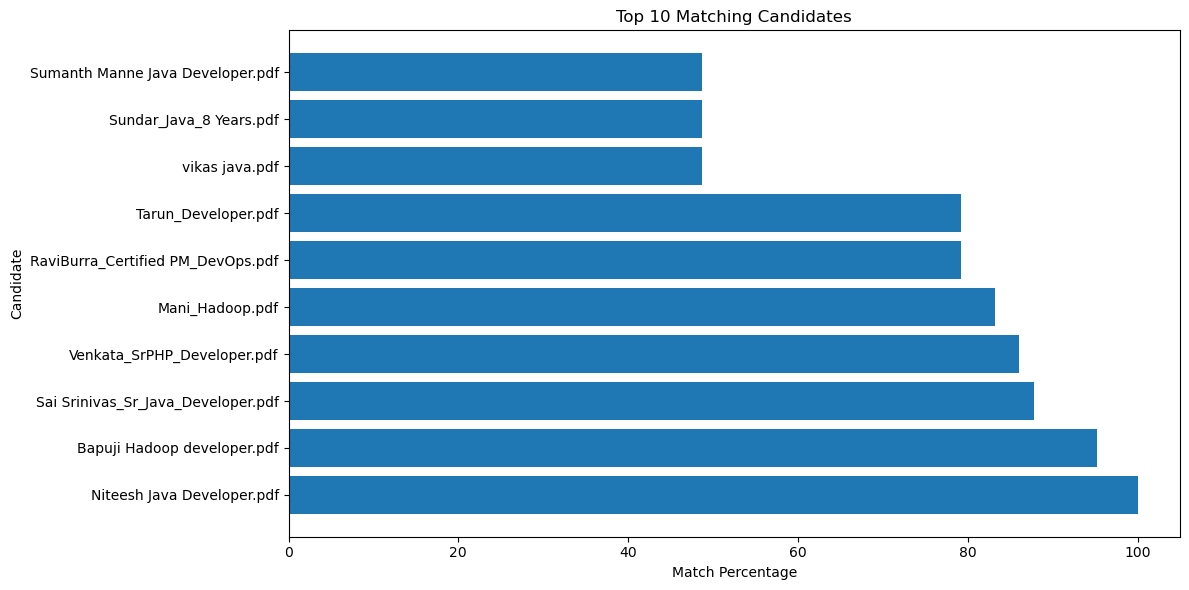

In [61]:
top_10 = ranked_candidates.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_10["resume_name"],
    top_10["match_percentage"]
)

plt.title(
    "Top 10 Matching Candidates"
)

plt.xlabel(
    "Match Percentage"
)

plt.ylabel(
    "Candidate"
)

plt.tight_layout()

plt.show()

In [62]:
ranked_candidates = ranked_candidates.reset_index(
    drop=True
)

ranked_candidates["ATS_Rank"] = (
    ranked_candidates.index + 1
)

In [63]:
ranked_candidates[
    [
        "ATS_Rank",
        "resume_name",
        "match_percentage",
        "skill_count"
    ]
].head(15)

,ATS_Rank,resume_name,match_percentage,skill_count
0,1,Niteesh Java Developer.pdf,100.000000,6
1,2,Bapuji Hadoop developer.pdf,95.176116,9
2,3,Sai Srinivas_Sr_Java_Developer.pdf,87.763342,8
3,4,Venkata_SrPHP_Developer.pdf,85.985031,6
4,5,Mani_Hadoop.pdf,83.230969,8
5,6,RaviBurra_Certified PM_DevOps.pdf,79.255553,6
6,7,Tarun_Developer.pdf,79.176417,6
7,8,vikas java.pdf,48.670268,6
8,9,Sundar_Java_8 Years.pdf,48.670268,6
9,10,Sumanth Manne Java Developer.pdf,48.670268,6


In [64]:
ranked_candidates.to_csv(
    r"D:\AI_ATS_Resume_Screening_System\resume\test\csv\candidate_ranking.csv",
    index=False
)

print("Candidate ranking saved successfully!")

Candidate ranking saved successfully!
